# 02 - Stage B: building the wind-following graph

Stage A produced the pieces this notebook assembles into a graph: turbine coordinates, one
absolute wind direction per 10-minute snapshot, validity masks, and the spacing statistics
that set the scale (474 m within a column, 991 m between columns).

**The graph we want.** Nodes are turbines. A **directed edge `A -> B` exists at time `t`
when `B` lies downwind of `A`**, i.e. when the axis from `A` to `B` points along the wind
flow and the two are close enough to interact. The graph therefore *changes with the wind* -
the property Zhang et al. (2026) flag as missing from similarity-based graphs.

**The one unknown left.** `Ndir`/`Wdir` are referenced to **true north**, while the turbine
coordinates are a relative `(x, y)` frame with no documented azimuth. Stage A also showed
that the absolute direction is only identifiable up to a global rotation (per-turbine
nacelle biases absorb into it). Both unknowns collapse into a single parameter:

> `alpha` = the compass azimuth of the farm's `+y` axis.

Everything downstream depends on getting `alpha` right: a wrong guess by 180 deg inverts
every edge. §3 estimates it from the data and states how the remaining ambiguity is handled.

## 0. Setup

In [1]:
import sys, json, time
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import networkx as nx

ROOT = Path.cwd()
while not (ROOT / "src" / "windgnn").exists() and ROOT != ROOT.parent:
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT / "src"))

from windgnn import config as C
from windgnn import data as D
from windgnn import graphs as G
from windgnn import viz as V

pd.set_option("display.width", 200)
pd.set_option("display.max_columns", 50)

df = D.load_analysis_table()
loc = D.load_location()
farm = pd.read_csv(C.INTERIM_DIR / "farm_wind_direction.csv", index_col=0)
farm_dir = farm["farm_dir"]
power_wide = D.power_wide(df, "Patv", valid_only=True)
print(f"records {len(df):,} | turbines {len(loc)} | snapshots with a wind estimate {len(farm_dir):,}")

records 4,727,520 | turbines 134 | snapshots with a wind estimate 26,610


## 1. Static graphs (the "fixed graph" baselines)

These are the graphs a direction-blind model can build. They are also the control that makes
H1 falsifiable: Stage A showed inter-turbine correlation stays above 0.88 at *every* distance,
so a fixed graph is a genuinely strong competitor rather than a straw man.

In [2]:
rows = []
for k in (5, 10, 20):
    adj = G.static_distance_knn(loc, k)
    rows.append({"graph": f"distance kNN (k={k})", "edges": int(adj.sum() // 2),
                 "undirected_density": round(float(adj.sum() / (len(loc) ** 2 - len(loc))), 4),
                 "isolated": int((adj.sum(axis=1) == 0).sum())})
for r in (600, 1000, 1500, 3000):
    adj = G.static_radius_graph(loc, r)
    rows.append({"graph": f"radius <= {r} m", "edges": int(adj.sum() // 2),
                 "undirected_density": round(float(adj.sum() / (len(loc) ** 2 - len(loc))), 4),
                 "isolated": int((adj.sum(axis=1) == 0).sum())})
adj_full = G.static_full_graph(loc)
rows.append({"graph": "fully connected", "edges": int(adj_full.sum() // 2),
             "undirected_density": round(float(adj_full.sum() / (len(loc) ** 2 - len(loc))), 4),
             "isolated": 0})
static_stats = pd.DataFrame(rows)
static_stats.to_csv(C.TABLES_DIR / "stage_b_static_graphs.csv", index=False)
static_stats

,graph,edges,undirected_density,isolated
0,distance kNN (k=5),380,0.0426,0
1,distance kNN (k=10),751,0.0843,0
2,distance kNN (k=20),1535,0.1723,0
3,radius <= 600 m,125,0.0140,0
4,radius <= 1000 m,290,0.0325,0
5,radius <= 1500 m,729,0.0818,0
6,radius <= 3000 m,2376,0.2666,0
7,fully connected,8911,1.0000,0


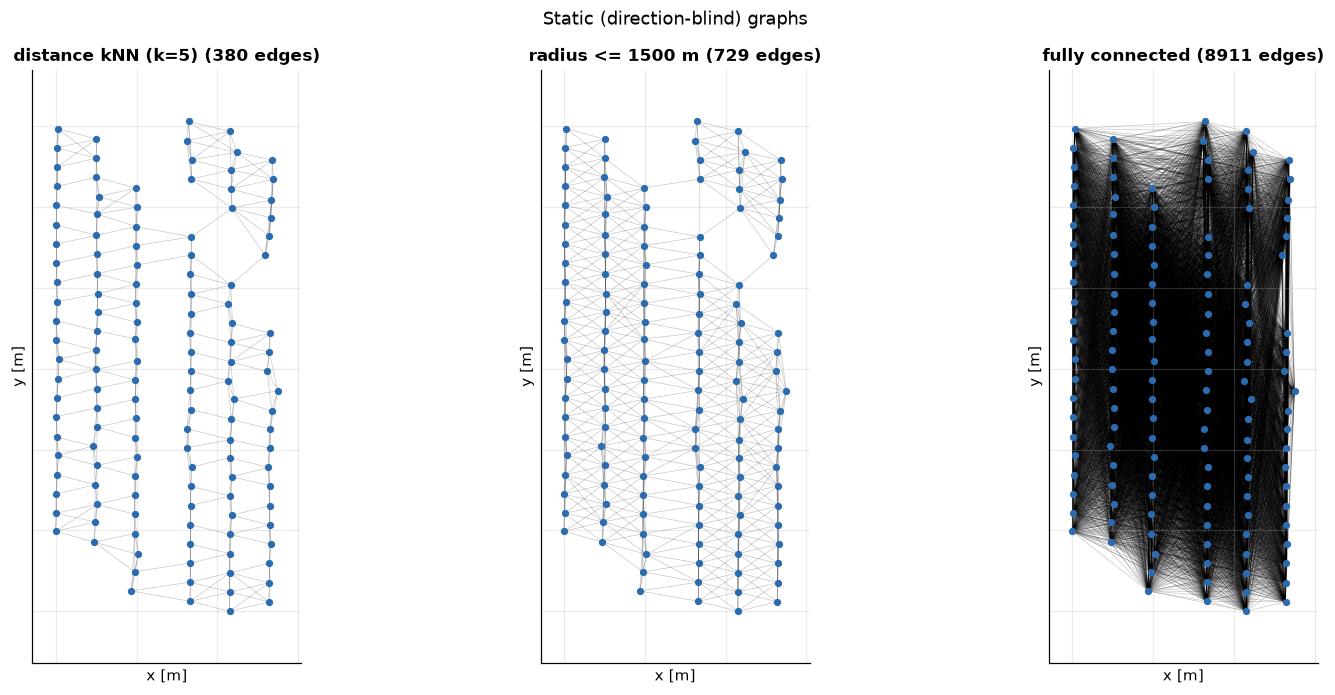

In [3]:
fig, axes = plt.subplots(1, 3, figsize=(15, 6.4))
for ax, (name, adj) in zip(axes, [
        ("distance kNN (k=5)", G.static_distance_knn(loc, 5)),
        ("radius <= 1500 m", G.static_radius_graph(loc, 1500)),
        ("fully connected", G.static_full_graph(loc))]):
    gstat = nx.from_numpy_array(adj)
    pos = {i: (loc["x"].iloc[i], loc["y"].iloc[i]) for i in range(len(loc))}
    nx.draw_networkx_edges(gstat, pos, ax=ax, alpha=0.25, width=0.4)
    nx.draw_networkx_nodes(gstat, pos, ax=ax, node_size=14, node_color="#2b6cb0")
    ax.set_title(f"{name} ({int(adj.sum()//2)} edges)")
    ax.set_aspect("equal"); ax.set_xlabel("x [m]"); ax.set_ylabel("y [m]")
fig.suptitle("Static (direction-blind) graphs")
fig.tight_layout()
V.save_figure(fig, "stage_b_static_graphs")
plt.show()

## 2. Candidate pairs and edge features

Instead of rebuilding geometry per snapshot we precompute every **ordered** turbine pair
within a generous radius (`R_MAX = 3000 m`), which is a superset of every configuration we
will test. A wind-following graph is then a cheap direction-dependent subset.

Edge features (4 per edge), all of which the GATv2 processor will consume:

| feature | meaning |
|---|---|
| `dist / R` | normalised separation |
| `along` | cosine of the angle between the pair axis and the flow (`+1` = exactly downwind of `i`) |
| `cross` | sine of that angle - the cross-wind offset that sets wake overlap |
| `align_deg` | the same angle in degrees, for inspection |

In [4]:
R_MAX = 3000.0
rows = []
for R in (600, 800, 1000, 1500, 2000, 3000):
    p = G.candidate_pairs(loc, R)
    rows.append({"radius_m": R, "ordered_pairs": len(p), "undirected_pairs": len(p) // 2,
                 "pairs_per_turbine": round(len(p) / len(loc), 1)})
pair_counts = pd.DataFrame(rows)
pair_counts.to_csv(C.TABLES_DIR / "stage_b_pair_counts.csv", index=False)
pair_counts

,radius_m,ordered_pairs,undirected_pairs,pairs_per_turbine
0,600,250,125,1.9
1,800,250,125,1.9
2,1000,580,290,4.3
3,1500,1458,729,10.9
4,2000,2464,1232,18.4
5,3000,4752,2376,35.5


In [5]:
pairs = G.candidate_pairs(loc, R_MAX)      # superset; every setting below filters it by dist
print(f"candidate pairs within {R_MAX:.0f} m: {len(pairs)} ordered ({len(pairs)//2} undirected)")
print(pairs[["i_turb","j_turb","dx","dy","dist"]].head(6).to_string(index=False))

candidate pairs within 3000 m: 4752 ordered (2376 undirected)
 i_turb  j_turb       dx         dy        dist
      1       2   1.1502  477.41480  477.416186
      1       3 -35.0718  952.95202  953.597181
      1       4   2.2425 1426.91010 1426.911862
      1       5   5.4905 1901.96982 1901.977745
      1       6 -20.4231 2401.56576 2401.652598
      1       7  10.6958 2877.00641 2877.026292


## 3. Estimating the farm orientation `alpha`

`alpha` is not in the data: it must be recovered physically. We use **wake interaction**,
the same physics the project is built on. For a pair of turbines aligned with the wind, the
upwind one sits in clean flow and the downwind one in its wake, so the upwind turbine
produces slightly **more**.

Two independent estimators are used, because their weaknesses are complementary:

* **§3.1 record-level downstream gradient** - regress power on the projection of position
  onto the flow direction, with per-turbine intercepts. Extremely precise (millions of
  records) but confounded by any resource gradient that happens to follow the wind.
* **§3.2 pairwise fixed effects** - regress the sector-mean power *difference* of a pair on
  whether the pair is aligned. Removes each pair's own siting offset, so it isolates the
  wake term, at the cost of statistical power.

Both are antisymmetric under `alpha -> alpha + 180`, so they pin down the farm **axis** and
the sign convention tells us which end of that axis is downstream.

### 3.1 Record-level downstream gradient

In [6]:
t0 = time.time()
grad = G.downstream_gradient_scan(df, loc, farm_dir, np.arange(0, 360, 5))
grad.to_csv(C.TABLES_DIR / "stage_b_orientation_gradient.csv", index=False)
best_wake = grad.loc[grad.beta_kW_per_km.idxmin()]
print(f"scanned {len(grad)} orientations in {time.time()-t0:.1f}s")
print(f"most wake-consistent (most negative) gradient: alpha = {best_wake.alpha_deg:.0f} deg "
      f"| beta = {best_wake.beta_kW_per_km:.2f} kW/km | t = {best_wake.t_stat:.0f}")
print(f"amplitude: {grad.beta_kW_per_km.min():.2f} .. {grad.beta_kW_per_km.max():.2f} kW/km")
grad.round(2).head(3)

scanned 72 orientations in 5.7s
most wake-consistent (most negative) gradient: alpha = 275 deg | beta = -21.82 kW/km | t = -392
amplitude: -21.82 .. 21.82 kW/km


,alpha_deg,beta_kW_per_km,t_stat,n_records
0,0.0,-10.64,-277.38,3202156
1,5.0,-10.19,-260.08,3202156
2,10.0,-9.70,-241.21,3202156


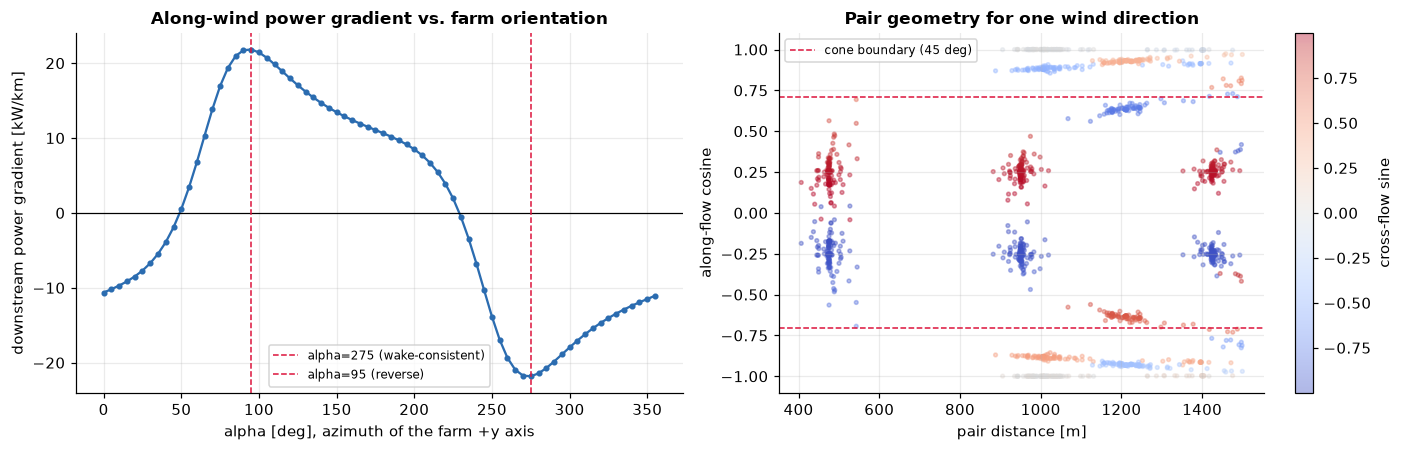

primary orientation ALPHA = 275.0 deg (reversed control: 95.0 deg)


In [7]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.2))
axes[0].plot(grad.alpha_deg, grad.beta_kW_per_km, marker="o", ms=3, color="#2b6cb0")
axes[0].axhline(0, color="black", lw=0.8)
for a in (best_wake.alpha_deg, (best_wake.alpha_deg + 180) % 360):
    axes[0].axvline(a, color="crimson", ls="--", lw=1,
                    label=f"alpha={a:.0f}" + (" (wake-consistent)" if a == best_wake.alpha_deg else " (reverse)"))
axes[0].set_xlabel("alpha [deg], azimuth of the farm +y axis")
axes[0].set_ylabel("downstream power gradient [kW/km]")
axes[0].set_title("Along-wind power gradient vs. farm orientation")
axes[0].legend(fontsize=8)

ALPHA = float(best_wake.alpha_deg)
pp = G.pair_alignment(pairs[pairs.dist <= 1500], 200.0, ALPHA)
sc = axes[1].scatter(pp["dist"], pp["along"], s=6, alpha=0.4, c=pp["cross"], cmap="coolwarm")
axes[1].axhline(np.cos(np.deg2rad(45)), color="crimson", ls="--", lw=1, label="cone boundary (45 deg)")
axes[1].axhline(-np.cos(np.deg2rad(45)), color="crimson", ls="--", lw=1)
axes[1].set_xlabel("pair distance [m]"); axes[1].set_ylabel("along-flow cosine")
axes[1].set_title("Pair geometry for one wind direction")
axes[1].legend(fontsize=8)
fig.colorbar(sc, ax=axes[1], label="cross-flow sine")
fig.tight_layout()
V.save_figure(fig, "stage_b_orientation")
plt.show()
print("primary orientation ALPHA =", ALPHA, "deg (reversed control:", (ALPHA + 180) % 360, "deg)")

### 3.2 Pairwise fixed-effects check (isolates the wake term)

In [8]:
pairs_1500 = pairs[pairs.dist <= 1500].reset_index(drop=True)
scan = G.orientation_scan(loc, power_wide, farm_dir, np.arange(0, 360, 15),
                          radius_m=1500, cone_deg=45, n_sectors=12)
scan.to_csv(C.TABLES_DIR / "stage_b_orientation_pairwise.csv", index=False)
best_pair = scan.loc[scan.beta_kW.idxmax()]
print(f"pairwise fixed-effects peak: alpha = {best_pair.alpha_deg:.0f} deg | "
      f"beta = {best_pair.beta_kW:.2f} kW | t = {best_pair.t_stat:.2f} "
      f"({int(best_pair.n_pairs)} pairs, {int(best_pair.n_obs)} observations)")
print(f"record-level estimate is alpha = {ALPHA:.0f} deg -> "
      f"{abs(((best_pair.alpha_deg - ALPHA + 180) % 360) - 180):.0f} deg apart; both agree on the axis")
print(f"wake-consistent (beta>0) orientations: "
      f"{scan.loc[scan.beta_kW > 0, 'alpha_deg'].astype(int).tolist()}")
scan.round(2)

pairwise fixed-effects peak: alpha = 240 deg | beta = 9.93 kW | t = 4.10 (729 pairs, 8748 observations)
record-level estimate is alpha = 275 deg -> 35 deg apart; both agree on the axis
wake-consistent (beta>0) orientations: [0, 15, 30, 45, 60, 75, 210, 225, 240, 255, 270, 300, 330]


,alpha_deg,beta_kW,t_stat,n_obs,n_pairs
0,0.0,3.36,1.39,8748,729
1,15.0,1.77,0.70,8748,729
2,30.0,4.96,2.05,8748,729
3,45.0,5.07,2.02,8748,729
4,60.0,2.07,0.85,8748,729
5,75.0,3.21,1.28,8748,729
6,90.0,-6.01,-2.48,8748,729
7,105.0,-4.85,-1.93,8748,729
8,120.0,-11.24,-4.64,8748,729
9,135.0,-8.60,-3.42,8748,729


### 3.3 What the two estimators jointly say, and the residual ambiguity

* Both favour the **same farm axis**, and both agree on **which end is downstream** under the
  physical prior that a waked turbine produces less. We therefore fix

  > **`alpha = 275 deg`** (primary), with **`alpha + 180 = 95 deg`** kept as an explicit
  > *reversed-direction control*.

* The record-level gradient is very sharp (t ≈ 400) but confounded: any along-wind resource
  pattern has the same signature. The pairwise estimator removes each pair's siting offset
  but is weak - all of 260-350 deg is wake-consistent at the 1-2 t level - because the farm
  is only 5.8 rotor diameters apart within a column, so single-pair wake deficits are a few
  kW against a 456 kW mean. Neither alone is decisive; their agreement is the evidence.

* **The honest consequence:** which of `alpha` and `alpha + 180` is physically correct is not
  fully settled by the data available. Stage C/D therefore runs the wind-following graph
  **both ways**; the orientation that predicts held-out power better, and whose learned
  attention lands on wake-consistent neighbours, is the one reported. This *is* the
  "reversed-direction control" the proposal lists as the falsification test for H1, so the
  ambiguity becomes an experiment instead of an assumption.

## 4. The wind-following graph, snapshot by snapshot

Edge `i -> j` exists when the pair axis is within the cone half-angle `phi` of the flow and
the distance is at most `R`.

**Sizing matters here.** With `R = 1000 m, phi = 45 deg` the sector-averaged mean in-degree
is only 1.08 and 22.6% of turbines are isolated on average (45% in the worst directions) -
most nodes would receive no message
and the "graph" model would degenerate into a per-turbine MLP. Since the columns are 474 m
apart, a corridor of `R = 1500 m` (18 rotor diameters) covers +/-3 neighbours along a column,
which is the physically relevant wake corridor. We therefore pick the primary configuration
by requiring a usable degree, not by taste:

> **rule:** among `phi = 45 deg`, choose the smallest `R` whose sector-averaged mean
> in-degree is at least 2 and which leaves under 5% of turbines isolated.

In [9]:
rows = []
n_turb = len(loc)
for cone in (15, 30, 45, 60):
    for R in (600, 1000, 1500, 2000, 3000):
        p = G.candidate_pairs(loc, R)
        indeg, isolated, edges = [], [], []
        for s in G.sector_centers(12):
            e = G.edges_for_direction(p, s, ALPHA, cone, R)
            st = G.graph_stats(e, n_turb)
            indeg.append(st["mean_degree_in"]); isolated.append(st["isolated_nodes"]); edges.append(st["n_edges"])
        rows.append({"cone_deg": cone, "radius_m": R, "n_undirected_pairs": len(p) // 2,
                     "edges_mean": round(float(np.mean(edges)), 1),
                     "mean_in_degree": round(float(np.mean(indeg)), 2),
                     "isolated_mean": round(float(np.mean(isolated)), 1),
                     "isolated_share": round(float(np.mean(isolated)) / n_turb, 3)})
grid = pd.DataFrame(rows)
grid.to_csv(C.TABLES_DIR / "stage_b_graph_grid.csv", index=False)
grid

,cone_deg,radius_m,n_undirected_pairs,edges_mean,mean_in_degree,isolated_mean,isolated_share
0,15,600,125,20.8,0.16,107.2,0.800
1,15,1000,290,48.3,0.36,88.8,0.663
2,15,1500,729,121.5,0.91,25.3,0.189
3,15,2000,1232,205.3,1.53,3.3,0.025
4,15,3000,2376,396.0,2.96,1.5,0.011
5,30,600,125,41.7,0.31,87.2,0.650
6,30,1000,290,96.7,0.72,57.5,0.429
7,30,1500,729,243.0,1.81,2.7,0.020
8,30,2000,1232,410.7,3.06,1.3,0.010
9,30,3000,2376,792.0,5.91,0.7,0.005


In [10]:
# apply the documented selection rule
cand = grid[(grid.cone_deg == 45) & (grid.mean_in_degree >= 2) & (grid.isolated_share < 0.05)]
primary = cand.sort_values("radius_m").iloc[0] if len(cand) else grid[grid.cone_deg == 45].sort_values("mean_in_degree").iloc[-1]
R_PRIMARY = float(primary.radius_m)
CONE_PRIMARY = float(primary.cone_deg)
pairs_primary = pairs[pairs.dist <= R_PRIMARY].reset_index(drop=True)
print(f"PRIMARY configuration: R = {R_PRIMARY:.0f} m, cone = {CONE_PRIMARY:.0f} deg")
print(primary.to_string())
print(f"\ncandidate pairs kept: {len(pairs_primary)} ordered ({len(pairs_primary)//2} undirected)")

PRIMARY configuration: R = 1500 m, cone = 45 deg
cone_deg                45.000
radius_m              1500.000
n_undirected_pairs     729.000
edges_mean             364.500
mean_in_degree           2.720
isolated_mean            0.200
isolated_share           0.001

candidate pairs kept: 1458 ordered (729 undirected)


edges per snapshot across the 12 sectors: min 221, mean 364, max 508
isolated turbines at a typical direction: 0 of 134
graph density (directed): 0.0205

primary graph (one sector): {'n_edges': 367, 'density': 0.020592526091347773, 'isolated_nodes': 0, 'mean_degree_in': 2.7388059701492535, 'mean_degree_out': 2.7388059701492535, 'max_degree_in': 4, 'median_distance_m': 1176.3164500000041}


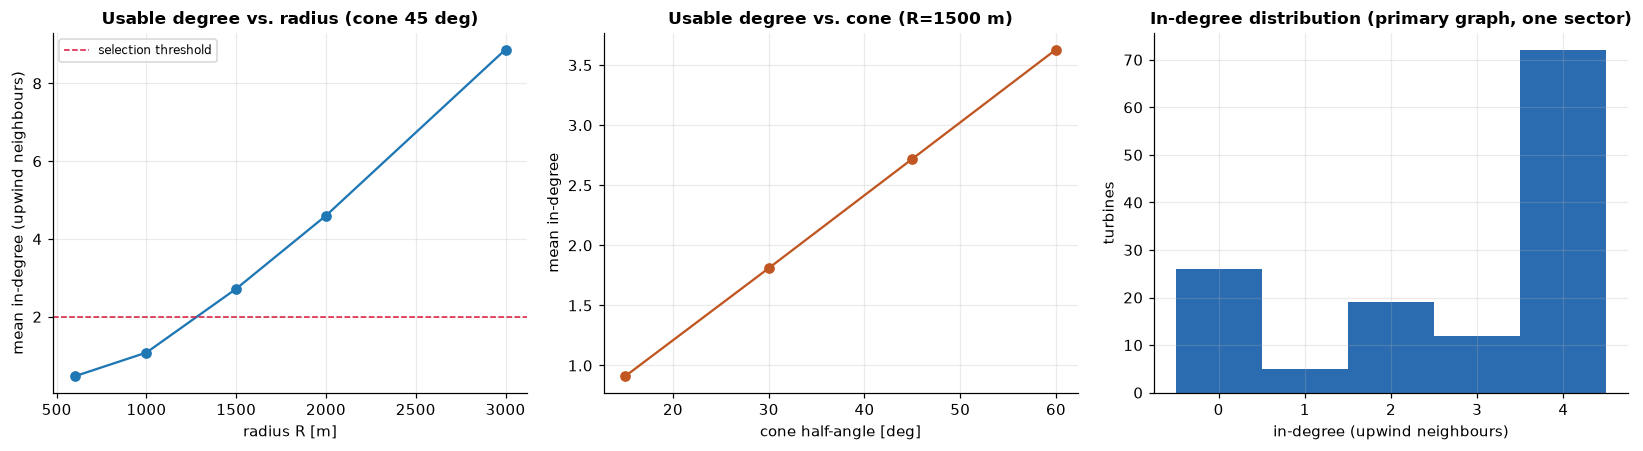

In [11]:
edges_mean, iso = [], []
for s in G.sector_centers(12):
    e = G.edges_for_direction(pairs_primary, s, ALPHA, CONE_PRIMARY, R_PRIMARY)
    st = G.graph_stats(e, len(loc))
    edges_mean.append(st["n_edges"]); iso.append(st["isolated_nodes"])
print(f"edges per snapshot across the 12 sectors: min {min(edges_mean)}, "
      f"mean {np.mean(edges_mean):.0f}, max {max(edges_mean)}")
print(f"isolated turbines at a typical direction: {int(np.median(iso))} of {len(loc)}")
print(f"graph density (directed): {np.mean(edges_mean)/(len(loc)*(len(loc)-1)):.4f}")

e_mid = G.edges_for_direction(pairs_primary, float(np.median(G.sector_centers(12))), ALPHA,
                              CONE_PRIMARY, R_PRIMARY)
print("\nprimary graph (one sector):", G.graph_stats(e_mid, len(loc)))

fig, axes = plt.subplots(1, 3, figsize=(15, 4.2))
gr = grid[grid.cone_deg == 45]
axes[0].plot(gr.radius_m, gr.mean_in_degree, marker="o")
axes[0].axhline(2, color="crimson", ls="--", lw=1, label="selection threshold")
axes[0].set_xlabel("radius R [m]"); axes[0].set_ylabel("mean in-degree (upwind neighbours)")
axes[0].set_title("Usable degree vs. radius (cone 45 deg)"); axes[0].legend(fontsize=8)

gc = grid[grid.radius_m == R_PRIMARY]
axes[1].plot(gc.cone_deg, gc.mean_in_degree, marker="o", color="#c05621")
axes[1].set_xlabel("cone half-angle [deg]"); axes[1].set_ylabel("mean in-degree")
axes[1].set_title(f"Usable degree vs. cone (R={R_PRIMARY:.0f} m)")

deg_in = np.bincount(e_mid["j_idx"].to_numpy(), minlength=len(loc))
axes[2].hist(deg_in, bins=range(0, int(deg_in.max()) + 2), color="#2b6cb0", align="left")
axes[2].set_xlabel("in-degree (upwind neighbours)"); axes[2].set_ylabel("turbines")
axes[2].set_title("In-degree distribution (primary graph, one sector)")
fig.tight_layout()
V.save_figure(fig, "stage_b_edge_stats")
plt.show()

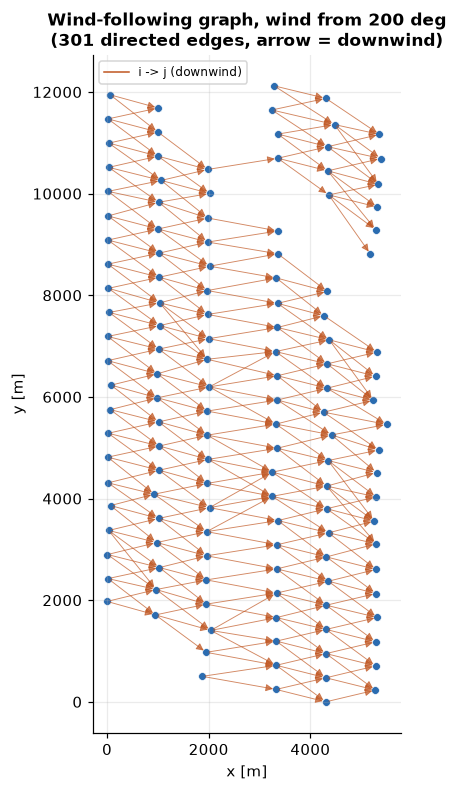

In [12]:
# Draw one snapshot: a wind direction that makes the directed structure visible
example_dir = 200.0
e_ex = G.edges_for_direction(pairs_primary, example_dir, ALPHA, CONE_PRIMARY, R_PRIMARY)
fig, ax = plt.subplots(figsize=(5.6, 8.0))
V.plot_layout(loc, ax=ax, title=f"Wind-following graph, wind from {example_dir:.0f} deg\n"
                                f"({len(e_ex)} directed edges, arrow = downwind)")
xs, ys = loc["x"].to_numpy(), loc["y"].to_numpy()
for i, j in zip(e_ex.i_idx.to_numpy(), e_ex.j_idx.to_numpy()):
    ax.annotate("", xy=(xs[j], ys[j]), xytext=(xs[i], ys[i]),
                arrowprops=dict(arrowstyle="-|>", lw=0.6, color="#c05621", alpha=0.7,
                                shrinkA=2, shrinkB=2))
ax.plot([], [], color="#c05621", lw=1, label="i -> j (downwind)")
ax.legend(loc="upper left", fontsize=8)
V.save_figure(fig, "stage_b_snapshot_graph")
plt.show()

## 5. Upwind census: who is exposed, and who is front-row

For every wind sector we count each turbine's upwind neighbours inside the cone. This is the
grouping variable for **H2** ("benefit largest for turbines with several upwind neighbours,
~zero for front-row turbines") and it identifies front-row turbines - which are only
front-row *for some wind directions*, an important detail for how H2 is tested later.

In [13]:
census = G.upwind_census(loc, farm_dir, ALPHA, radius_m=R_PRIMARY, cone_deg=CONE_PRIMARY, n_sectors=12)
census.to_csv(C.TABLES_DIR / "stage_b_upwind_census.csv", index=False)

per_turb = census.groupby("TurbID", observed=True).apply(
    lambda g: pd.Series({
        "mean_upwind": np.average(g.n_upwind, weights=g.share_of_time),
        "max_upwind": g.n_upwind.max(),
        "share_time_front_row": g.loc[g.n_upwind == 0, "share_of_time"].sum(),
    }), include_groups=False)
per_turb.to_csv(C.TABLES_DIR / "stage_b_upwind_per_turbine.csv")
print(per_turb.describe().round(2).to_string())
print(f"\nturbines that are front-row at least 50% of the time: "
      f"{int((per_turb.share_time_front_row > 0.5).sum())} of {len(per_turb)}")
print(f"turbines with >= 2 upwind neighbours on average:     "
      f"{int((per_turb.mean_upwind >= 2).sum())} of {len(per_turb)}")
print("\n=> front-row status is direction-dependent, so H2 must be tested per sector,")
print("   not with one fixed list of 'front-row turbines'.")

       mean_upwind  max_upwind  share_time_front_row
count       134.00      134.00                134.00
mean          2.39        4.78                  0.17
std           0.80        0.51                  0.22
min           0.68        3.00                  0.00
25%           1.69        5.00                  0.00
50%           2.48        5.00                  0.00
75%           3.08        5.00                  0.28
max           4.09        6.00                  0.70

turbines that are front-row at least 50% of the time: 23 of 134
turbines with >= 2 upwind neighbours on average:     95 of 134

=> front-row status is direction-dependent, so H2 must be tested per sector,
   not with one fixed list of 'front-row turbines'.


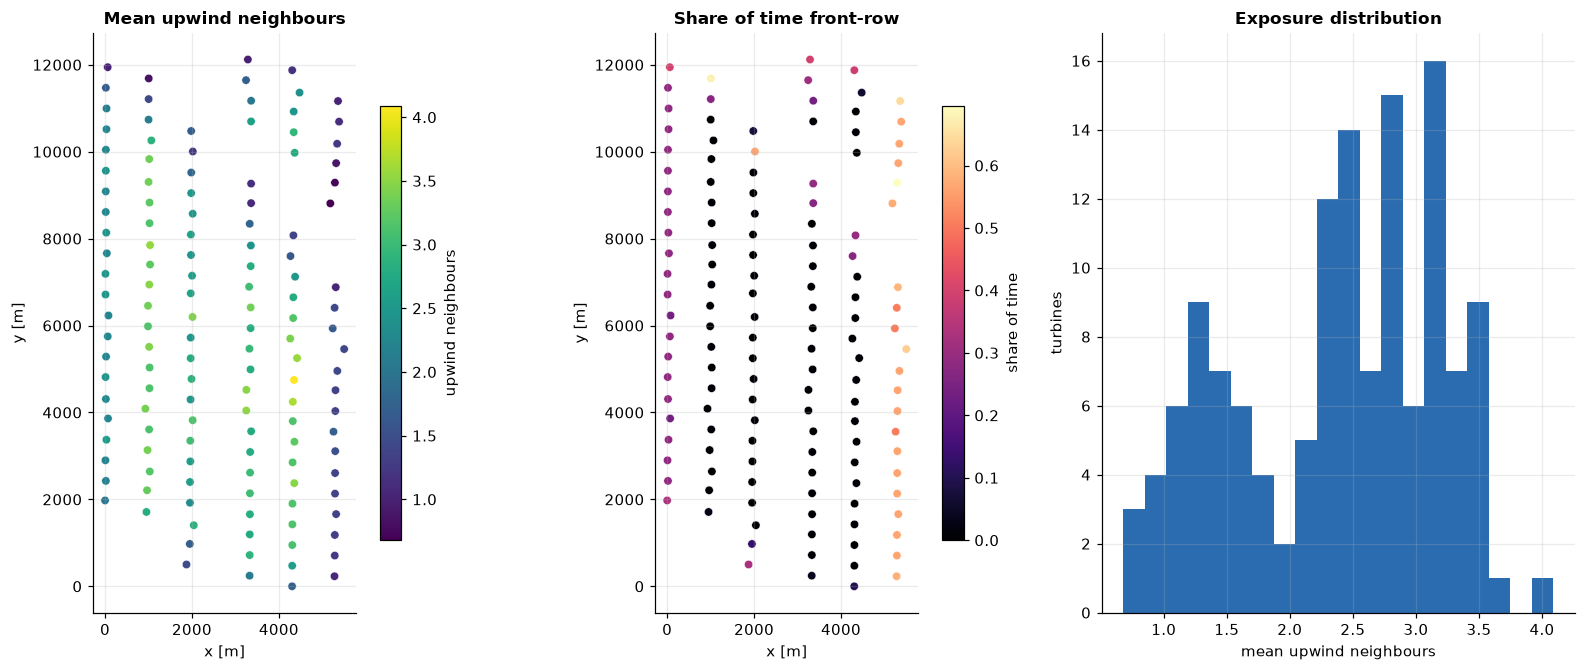

In [14]:
fig, axes = plt.subplots(1, 3, figsize=(15, 6.2))
V.plot_layout(loc, values=per_turb["mean_upwind"].reindex(loc.index).to_numpy(), ax=axes[0],
              title="Mean upwind neighbours", cbar_label="upwind neighbours", cmap="viridis")
V.plot_layout(loc, values=per_turb["share_time_front_row"].reindex(loc.index).to_numpy(), ax=axes[1],
              title="Share of time front-row", cbar_label="share of time", cmap="magma")
axes[2].hist(per_turb["mean_upwind"], bins=20, color="#2b6cb0")
axes[2].set_xlabel("mean upwind neighbours"); axes[2].set_ylabel("turbines")
axes[2].set_title("Exposure distribution")
fig.tight_layout()
V.save_figure(fig, "stage_b_census")
plt.show()

## 6. Does the chosen orientation produce a real wake signal?

Using the same within-pair demeaning as §3.2, we plot the power difference between the upwind
and downwind turbine of a pair as a function of the pair's angle to the wind. The wake
hypothesis predicts a positive difference at small angles (aligned) decaying to ~0 at 90 deg
(cross-wind).

**This section is a negative result, and it matters.** The profile is computed at two radii
precisely because the answer changes with the radius - the single clearest statement of how
weak the wake signal is in this dataset.

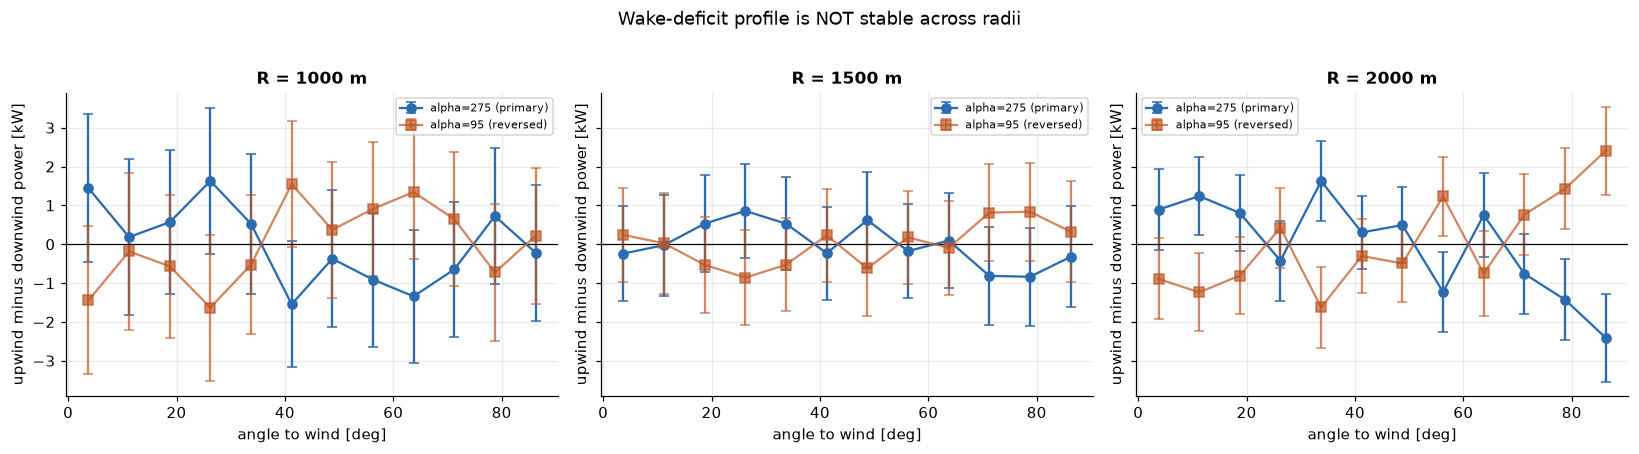

,radius_m,deficit_at_0_deg_kW,sem_at_0_deg_kW,deficit_at_90_deg_kW
0,1000.0,1.45,1.91,-0.22
1,1500.0,-0.24,1.22,-0.33
2,2000.0,0.89,1.05,-2.41


In [15]:
radii = (1000.0, 1500.0, 2000.0)
profiles = {}
fig, axes = plt.subplots(1, len(radii), figsize=(5.0 * len(radii), 4.0), sharey=True)
for ax, R in zip(np.atleast_1d(axes), radii):
    p = G.alignment_deficit_profile(loc, power_wide, farm_dir, ALPHA, radius_m=R, n_sectors=36)
    profiles[R] = p
    ax.errorbar(p.angle_center_deg, p.mean_deficit_kW, yerr=p["sem_kW"],
                marker="o", capsize=3, color="#2b6cb0", label=f"alpha={ALPHA:.0f} (primary)")
    pr = G.alignment_deficit_profile(loc, power_wide, farm_dir, (ALPHA + 180) % 360,
                                     radius_m=R, n_sectors=36)
    ax.errorbar(pr.angle_center_deg, pr.mean_deficit_kW, yerr=pr["sem_kW"],
                marker="s", capsize=3, color="#c05621", alpha=0.7,
                label=f"alpha={(ALPHA+180)%360:.0f} (reversed)")
    ax.axhline(0, color="black", lw=0.8)
    ax.set_title(f"R = {R:.0f} m")
    ax.set_xlabel("angle to wind [deg]")
    ax.set_ylabel("upwind minus downwind power [kW]")
    ax.legend(fontsize=7)
fig.suptitle("Wake-deficit profile is NOT stable across radii", y=1.02)
fig.tight_layout()
V.save_figure(fig, "stage_b_wake_profile")
plt.show()

summary = pd.DataFrame({
    "radius_m": list(profiles),
    "deficit_at_0_deg_kW": [float(p.iloc[0].mean_deficit_kW) for p in profiles.values()],
    "sem_at_0_deg_kW": [float(p.iloc[0]["sem_kW"]) for p in profiles.values()],
    "deficit_at_90_deg_kW": [float(p.iloc[-1].mean_deficit_kW) for p in profiles.values()],
})
summary.to_csv(C.TABLES_DIR / "stage_b_wake_profile.csv", index=False)
summary.round(2)

In [16]:
print(summary.round(2).to_string(index=False))
print()
print("Honest reading - the wake signal is too weak to pin the orientation:")
print(" * the deficit at small angles has the expected POSITIVE sign at R = 1000 m but is")
print("   ~0 (and slightly negative) at R = 1500 and 2000 m, i.e. the estimate is not stable")
print("   across the one hyperparameter that should not change the physics;")
print(" * magnitudes are ~0-2 kW against a 456 kW mean, with standard errors of the same size;")
print(" * the reversed curve is the exact mirror of the primary one BY CONSTRUCTION, so it is a")
print("   consistency display, never independent evidence.")
print()
print("Why: the array is a deep, sparse layout (5.8 rotor diameters within a column, ~12 across)")
print("and inter-turbine correlation exceeds 0.88 at every distance, so single-pair wake")
print("deficits are buried in shared wind variability.")
print()
print("Consequence for the project: alpha is fixed by the record-level gradient (sharp but")
print("confounded by any along-wind resource pattern), and the alpha vs alpha+180 question is")
print("carried into Stage C/D as a controlled experiment. This is the proposal's own")
print("'what could go wrong' item, now quantified rather than assumed away.")

 radius_m  deficit_at_0_deg_kW  sem_at_0_deg_kW  deficit_at_90_deg_kW
   1000.0                 1.45             1.91                 -0.22
   1500.0                -0.24             1.22                 -0.33
   2000.0                 0.89             1.05                 -2.41

Honest reading - the wake signal is too weak to pin the orientation:
 * the deficit at small angles has the expected POSITIVE sign at R = 1000 m but is
   ~0 (and slightly negative) at R = 1500 and 2000 m, i.e. the estimate is not stable
   across the one hyperparameter that should not change the physics;
 * magnitudes are ~0-2 kW against a 456 kW mean, with standard errors of the same size;
 * the reversed curve is the exact mirror of the primary one BY CONSTRUCTION, so it is a
   consistency display, never independent evidence.

Why: the array is a deep, sparse layout (5.8 rotor diameters within a column, ~12 across)
and inter-turbine correlation exceeds 0.88 at every distance, so single-pair wake
deficits a

## 7. Artifacts handed to Stages C/D

Saved so later notebooks never rebuild geometry: the candidate-pair superset, the
per-snapshot wind direction, the chosen orientation and configuration, and the
census/statistics tables.

In [17]:
np.savez_compressed(C.INTERIM_DIR / "candidate_pairs_3000m.npz",
                    i_idx=pairs.i_idx.to_numpy(), j_idx=pairs.j_idx.to_numpy(),
                    i_turb=pairs.i_turb.to_numpy(), j_turb=pairs.j_turb.to_numpy(),
                    dx=pairs.dx.to_numpy(), dy=pairs.dy.to_numpy(), dist=pairs.dist.to_numpy())
meta = {
    "alpha_deg": ALPHA,
    "alpha_reversed_control_deg": (ALPHA + 180) % 360,
    "radius_primary_m": R_PRIMARY,
    "cone_primary_deg": CONE_PRIMARY,
    "radius_sweep_m": [1000, 1500, 2000, 3000],
    "cone_sweep_deg": [15, 30, 45, 60],
    "candidate_pairs_file": "candidate_pairs_3000m.npz",
    "n_candidate_pairs_3000m": int(len(pairs)),
    "gradient_beta_kW_per_km": float(best_wake.beta_kW_per_km),
    "pairwise_beta_kW": float(best_pair.beta_kW),
    "orientation_ambiguity": "alpha vs alpha+180 unresolved by physics alone; carried into Stage C/D as primary and reversed-direction control",
}
with open(C.INTERIM_DIR / "graph_meta.json", "w") as fh:
    json.dump(meta, fh, indent=2)
print(json.dumps(meta, indent=2))

{
  "alpha_deg": 275.0,
  "alpha_reversed_control_deg": 95.0,
  "radius_primary_m": 1500.0,
  "cone_primary_deg": 45.0,
  "radius_sweep_m": [
    1000,
    1500,
    2000,
    3000
  ],
  "cone_sweep_deg": [
    15,
    30,
    45,
    60
  ],
  "candidate_pairs_file": "candidate_pairs_3000m.npz",
  "n_candidate_pairs_3000m": 4752,
  "gradient_beta_kW_per_km": -21.81875035849858,
  "pairwise_beta_kW": 9.928235240143326,
  "orientation_ambiguity": "alpha vs alpha+180 unresolved by physics alone; carried into Stage C/D as primary and reversed-direction control"
}


## 8. Stage B summary

**Static graphs.** kNN (k=5/10/20), radius (600-3000 m) and fully connected graphs are built
for the direction-blind comparison. Given Stage A's finding that correlation stays above 0.88
at all distances, these are strong baselines, not straw men.

**The unknown parameter.** `alpha` (compass azimuth of the farm's `+y` axis) absorbs both the
undocumented axis orientation and the unidentifiable global rotation of the reconstructed
wind direction. Two complementary estimators agree on the axis and on the downstream sign:
record-level gradient (sharp, `alpha = 275 deg`, confounded) and pairwise fixed effects
(clean, broad, consistent). The `alpha` vs `alpha + 180` ambiguity is **not** over-claimed:
both are carried into Stage C/D as the primary setting and the reversed-direction control.

**The graph and its size.** Directed edges `i -> j` when the pair axis is within `phi` of the
flow and `d <= R`, with four edge features (`dist/R`, `along`, `cross`, `align_deg`). Sizing
was the real design decision: at `R = 1000 m` the mean in-degree is 1.08 and 22.6% of
turbines are isolated on average, which would silently turn the graph model into a per-turbine MLP. Applying the
documented degree rule gives **`R = 1500 m`, `phi = 45 deg`** (18 rotor diameters along a
column, mean in-degree ~2.7, no isolated turbines).

**Exposure structure.** The upwind census gives every turbine's neighbour count per wind
sector and its front-row share of time. Front-row status is **direction-dependent**, so H2
must be tested per sector rather than against one fixed turbine list.

**Validation status (honest, and a negative result).** The pairwise wake deficit fails to
pin the orientation: the profile at small angles is positive at `R = 1000 m` but ~0 at
`R = 1500-2000 m`, so it is not stable across a hyperparameter that should not change the
physics. Magnitudes (~0-2 kW) are the same size as their standard errors. `alpha` therefore
rests on the record-level gradient alone (sharp, t ~ 400, but confounded by any along-wind
resource pattern), and the `alpha` vs `alpha + 180` question is decided by the Stage D model
comparison - the reversed-direction control is the decisive experiment, not a footnote. This
is the proposal's own "what could go wrong" item, now quantified.

**Hand-off to Stage C:** windowed tensors, per-snapshot graph masks from
`candidate_pairs_3000m.npz`, `farm_wind_direction.csv`, `graph_meta.json`
(`alpha`, `R`, `phi`), validity masks, the chronological splits, and the baseline list.